# 02 Detection evaluation

Detector metrics on the frozen dataset under `eval/dataset/`, with Wilson 95% confidence intervals. The same quantities gate CI on the smaller deterministic preset (`tests/unit/test_detectors_ground_truth.py`); this notebook reports them on the full session with per-pattern breakdown.

In [1]:
import json, sys
sys.path.insert(0, "../src")
import pandas as pd
from datagen.config import GeneratorConfig
from detection.detectors import run_detection
from evaluation.harness import detection_metrics
from schemas.events import GroundTruthEpisode

events = pd.read_parquet("../eval/dataset/events.parquet")
episodes = [GroundTruthEpisode(**e) for e in json.load(open("../eval/dataset/ground_truth.json"))]
ticks = {s.symbol: s.tick_size for s in GeneratorConfig.full().instruments}
hits = run_detection(events, ticks)
print(f"{len(events):,} events, {len(episodes)} episodes, {len(hits)} hits")

263,872 events, 42 episodes, 130 hits


In [2]:
m = detection_metrics(hits, episodes, events)
for k in ("family_recall", "exact_recall", "hit_precision", "false_positive_rate"):
    print(f"{k:>24}: {m[k]}")
print(f"{'false positive hits':>24}: {m['n_false_positive_hits']} of {m['n_hits']}")

           family_recall: 1.000 (42/42, 95% CI 0.916-1.000)
            exact_recall: 0.976 (41/42, 95% CI 0.877-0.996)
           hit_precision: 1.000 (130/130, 95% CI 0.971-1.000)
     false_positive_rate: 0.000 (0/59098, 95% CI 0.000-0.000)
     false positive hits: 0 of 130


In [3]:
rows = [{"pattern": p, "recall": v.value, "ci_low": v.ci_low, "ci_high": v.ci_high,
         "episodes": v.n} for p, v in m["recall_by_pattern"].items()]
pd.DataFrame(rows).set_index("pattern").round(3)

,recall,ci_low,ci_high,episodes
pattern,,,,
layering,1.0,0.785,1.0,14
quote_stuffing,1.0,0.610,1.0,6
spoofing,1.0,0.785,1.0,14
wash_trading,1.0,0.676,1.0,8


Interval widths reflect episode counts: fourteen spoofing episodes bound recall much tighter than six quote-stuffing episodes, which is why the harness reports the interval rather than the point estimate alone.

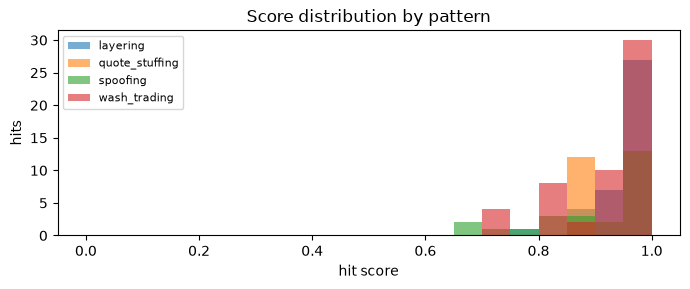

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3))
for pat, grp in hits.groupby("pattern"):
    ax.hist(grp["score"], bins=20, range=(0, 1), alpha=0.6, label=pat)
ax.set_xlabel("hit score"); ax.set_ylabel("hits"); ax.legend(fontsize=8)
ax.set_title("Score distribution by pattern")
plt.tight_layout()

**Caveats.** These numbers describe the synthetic generator's injections, not production performance. The generator's manipulation episodes are stylized and its benign flow is simpler than real order flow; see `docs/SYNTHETIC.md`.